<a href="https://colab.research.google.com/github/andlatorre/HIDROINFORMATICA_PARCIAL/blob/main/%5BHIDROINFORMATICA%5DPunto1_Clarke2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESARROLLO DEL PRIMER PROBLEMA**
*Douglas A. Gómez-Latorre-S1_2026**

El primer paso realizado para el desarrollo del problema, fue realizar la replicación del articulo *Clarke, R.T. (2002). "Estimating time trends in Gumbel-distributed data by means of generalized linear models." Water Resources Research, 38(7).111 https://doi.org/10.1029/2001WR000917* el cual contiene la totalidad de la información utilizada para el desarrollo del trabajo científico.

*Douglas A. Gómez-Latorre-S1_2026**


# **Síntesis del árticulo realizado por Clarke:**

De manera general, como marco introductorio del desarrollo, el articulo realiza un análisis de dos series temporales de Flujo Diario Máximo Anual [m3/s], para dos estaciones hidrométricas (Espumoso y Passo BelaVista) ubicadas en la rivera del río Jacuí al sur de Brasil. Los datos máximos anuales indican "Inundación Anual", por lo cual se puede asimilar que siguen una distribución de extremos. Así mismo, el trabajo propuso el uso de Modelos Lineales Generalizados (GLM) ajustados mediante el algoritmo de mínimos cuadrados iterativamente reponderados (IWLS, iteratively weighted least squares) para detectar tendencias temporales en datos que siguen una distribución de máximos como lo es la de Gumbel. Esto es relevante para caudales máximos anuales e intensidades máximas de lluvia, donde la distribución Gumbel es habitualmente utilizada. No obstante, el autor señala una inconsistencia lógica en la práctica convencional cuando se usa esta distribución: si se sospecha tendencia en datos de extremos (que deberían ser Gumbel), se prueba esa tendencia con regresión lineal (que asume normalidad) o con Mann-Kendall (que descarta toda hipótesis distribucional). Ambos métodos desperdician la información de que los datos son Gumbel.

# **Análisis del problema**
De acuerdo con el enunciado *Seleccione una de las dos series de tiempo de caudales máximos anuales de la Tabla 1 y reproduzca la estimación de parámetros de la distribución Gumbel considerando una variación temporal de los mismos y el método de la máxima verosimilitud. Compare sus resultados con los reportados por el artículo en la Tabla 2.* el análisis reporta las siguientes consideraciones:


**1. Estación ESPUMOSO (1941-1993)**

De forma general, tal como se observa en la tabla adjunta [Revisar ANEXO1, donde se replica el código], los valores de la estación **ESPUMOSO** (seleccionada para el análisis) convergen en la cuarta iteración, similar a lo obtenido por Clarke.  De esta manera, conceptualmente el parámetro *alpha* nos permite conocer la dispersion de los caudales máximos alrededor del valor medio de la serie de tiempo de caudal.  Si con el valor valor obtenido (*alpha=0.3401*), calculamos la desviación estandar de una distribución Gumbel (sigma=PI/alpha*raiz(6)), como resultado obtenemos que el valor de *sigma=369.6 m³/s* es la variación anual para el periodo 1941-1993 de los caudales máximos alrededor del valor medio.

Así mismo, el parámetro *m*, que no es más que un parámetro de localización del valor de la distribución en su forma inicial (t=0), nos puede indicar que para 1941 (dado que en 1940 existe un valor ausente), el valor esperado en la longitud de la distribución es de **315.02 m³/s**, una cifra relativamente alta en terminos los valores de caudal anual.   

Finalmente, el parametro *beta*, es un indicador de la tasa de cambio de la media del caudal máximo anual por unidad de tiempo. En otras palabras, indica la tendencia de los valores de caudal máximo, ya que si la serie presenta tendencia, es probable que se descarte la estacionaridad. Este valor converge  a 5.96 m³/ por año. Esto significa que la media del caudal máximo anual aumenta ~5.96 m³/s cada año. Con un registro de 53 años (1941–1993), el incremento total estimado es ≈ 316 m³/s, que es sustancial respecto a la media.

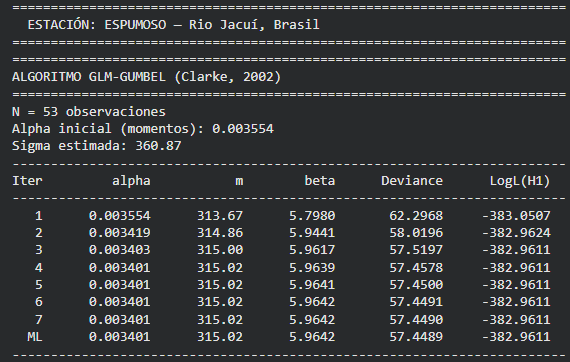

2.   Estación ESPUMOSO - Variación temporal de la ventana (1950-1990)

Ahora bien, cuando se realiza una variación de la ventana temporal [Revisar ANEXO2, donde se replica el código], los parámetros sufren un ligero cambio, sobre todo debido a la perdida de algunos valores extremos que ajustan la distribución de la Gumbel.

En el caso del parámetro *alpha*, el cual converge en *alpha=0.003469*, el valor de la desvaición estandar de gumbel, es 369.6 m³/s, lo que se traduce en que la variabilidad interanual de los caudales máximos es mucho mayor, lo cual en un año típico, el caudal máximo puede desviarse casi 370 m³/s respecto a la media esperada para ese año.

De la misma forma, el parámetro m, estimado = 112.58 m³/s, está orientado a indicarnos la sensibilidad al origen temporal.  En el caso de la ventana 1941-1993, el t=0 se daba en el inicio de la serie, mientras que ahora ese t=0 está en el año 1950, lo que indica que ese valor inicial está fuertemente alterado, pero la tendencia, puede seguir siendo la misma.

Finalmente el parametro beta calculado para esta ventana es de 12.74 m³/s, lo que se traduce que la media del caudal máximo anual aumenta ~12.74 m³/s cada año. Con un registro de 41 años (1950–1993), el incremento total estimado es ≈ 510 m³/s, muy por encima al del periodo completo.  Tal como se describió en el punto anterior, beta no solo mueve la media, si no que desplaza toda la distribución hacia la derecha con el tiempo. Esto se traduce de forma concreta que las medidas de tendencia central y todos los cuantiles aumentan simultáneamente a la misma tasa beta. Nada más si se analiza un caudal para el período de retorno t= 100 años en 1990 es de 509.6 m³/s mayor que el de 1950.

Como conclusión, una de las cosas imporates del análsis de Clarke y probado con la variación de la ventana temporal es que cuando beta es diferente de 0, el concepto de "creciente con período de retorno T años" pierde sentido porque el cuantil depende de en qué año lo evalúes.Esto se pudo observar cuando los valores de m convergían de manera satisfactoria para la estación Passo Bela Vista, porque en realidad comenzaba en el periodo t=0, mientras para Espumoso, el valor faltante asimilaba que ese era el mismo inicio del periodo, mientras que en realidad era en 1941.

Finalmente, entre los métodos de maxima verosimilitud, que nos da el beta mencionado de 12.74 m³/s comparado con el beta de minimos cuadrados ordinarios (OLS) con un valor de 14.19 m³/s, radica en que la regresión líneal de este último metodo sobreestima la tendencia en 1.45 m³/s/año porque los valores extremos altos (cola derecha de la Gumbel) ejercen un apalancamiento desproporcionado bajo dado que trabaja bajo supuesto de normalidad. Para la serie hidrológica en cuestión, esa diferencia se acumula, obteniendo 58 m³/s más que el dado apartir de maxima verosimilitud.

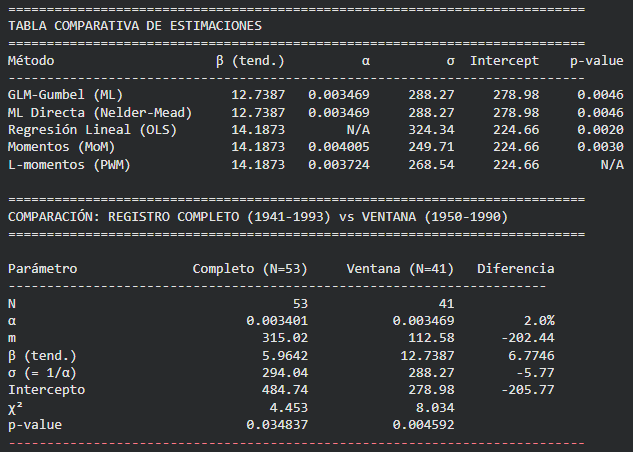

A continuación, en los Anexos se pueden observar los codigos realizados para el análisis



# [ANEXO1] Replicación del código general para el periodo de referencia
*(Script generado orientación a partir de Claude-IA)*

In [ ]:
!pip install numpy scipy matplotlib

import numpy as np
from scipy.optimize import brentq
from scipy.stats import chi2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# =============================================================================
# 1. DATOS DE LA TABLA 1 — Rio Jacuí, Brasil (1940–1993)
# =============================================================================

# Espumoso: 1941–1993 (1940 es dato faltante)
years_espumoso = np.arange(1941, 1994)
flows_espumoso = np.array([
    312, 590, 248, 670, 365, 770, 465, 545, 315, 115,
    232, 260, 655, 675, 455, 1020, 700, 570, 853, 395,
    926, 99, 680, 121, 976, 916, 921, 191, 187, 377,
    128, 582, 744, 710, 520, 672, 645, 655, 918, 512,
    255, 1126, 1386, 1394, 600, 950, 731, 700, 1407, 1284,
    165, 1496, 809
], dtype=float)

# Passo Bela Vista: 1940–1993
years_belavista = np.arange(1940, 1994)
flows_belavista = np.array([
    900, 1678, 866, 455, 761, 510, 674, 548, 621, 415,
    1495, 346, 354, 985, 1186, 680, 1525, 785, 1062, 1074,
    607, 1124, 132, 868, 615, 1068, 1062, 1225, 313, 278,
    619, 1121, 1498, 1062, 1309, 674, 1017, 796, 692, 1202,
    785, 391, 1501, 1933, 1726, 796, 1239, 1009, 931, 1593,
    1423, 293, 1790, 905
], dtype=float)

In [ ]:
# =============================================================================
# 2. FUNCIONES DEL ALGORITMO GLM-GUMBEL (Clarke, 2002)
# =============================================================================

def gumbel_initial_alpha(y):
    """
    Paso 1: Estimación inicial de alpha por momentos.
    alpha_tilde = pi / (s_tilde * sqrt(6))
    """
    s = np.std(y, ddof=1)
    return np.pi / (s * np.sqrt(6))


def glm_iwls_gumbel(y, X, alpha, max_iter_iwls=50, tol_iwls=1e-8):
    """
    Paso 2: Ajuste GLM con función de enlace logarítmica (log-link)
    para la variable transformada w = exp(-alpha * y) > 0.

    Dado que Y ~ Gumbel(m, alpha), la variable W = exp(-alpha*Y)
    sigue una distribución Exponencial(theta) con theta = exp(alpha*m),
    que es un caso especial de la Gamma (forma = 1).

    Para la Gamma con log-link:
      - Función de varianza: V(mu) = mu^2
      - Enlace: log(mu) = eta = X @ beta_glm
      - dmu/deta = mu
      - Pesos IWLS: w_i = (dmu/deta)^2 / V(mu) = mu^2/mu^2 = 1

    El predictor lineal es:
      eta_i = beta_glm[0] + beta_glm[1]*t_i = -alpha*m - alpha*beta*t_i

    Parámetros
    ----------
    y : array, datos originales
    X : array (N x p), matriz de diseño [1, t] o [1, t, t^2, ...]
    alpha : float, valor actual de alpha

    Retorna
    -------
    beta_glm : array, coeficientes del GLM en escala transformada
    mu_hat : array, valores ajustados de mu (E[W])
    deviance : float, deviance del modelo (Gamma deviance)
    """
    w = np.exp(-alpha * y)  # W = exp(-alpha*Y) > 0
    N = len(w)

    # Valores iniciales: log(w) = -alpha*y, regresión de log(w) ~ X
    log_w = np.log(w)
    beta_glm = np.linalg.lstsq(X, log_w, rcond=None)[0]

    for iteration in range(max_iter_iwls):
        eta = X @ beta_glm
        mu = np.exp(eta)  # mu = E[W] > 0

        # Variable de trabajo (adjusted dependent variable)
        # z_work = eta + (w - mu) / (dmu/deta) = eta + (w - mu) / mu
        z_work = eta + (w - mu) / mu

        # Pesos son TODOS 1 para Gamma con log-link
        # => IWLS se reduce a OLS: beta = (X^T X)^{-1} X^T z_work
        beta_new = np.linalg.lstsq(X, z_work, rcond=None)[0]

        # Verificar convergencia
        if np.max(np.abs(beta_new - beta_glm)) < tol_iwls:
            beta_glm = beta_new
            break
        beta_glm = beta_new

    # Valores ajustados finales
    eta = X @ beta_glm
    mu_hat = np.exp(eta)

    # Deviance para la familia Gamma (con phi=1):
    # D = 2 * sum{ (w_i - mu_i)/mu_i - log(w_i/mu_i) }
    # D = 2 * sum{ w_i/mu_i - 1 - log(w_i/mu_i) }
    r = w / mu_hat
    deviance = 2.0 * np.sum(r - 1.0 - np.log(r))

    return beta_glm, mu_hat, deviance


def solve_alpha_ml(y, m, beta_trend, X_trend, alpha_current):
    """
    Paso 3: Resolver la ecuación de máxima verosimilitud para alpha.

    Ecuación (8) del paper:
      N/alpha - sum(y_i - m - beta^T x_i)
      + sum( (y_i - m - beta^T x_i) * exp(-alpha*(y_i - m - beta^T x_i)) ) = 0

    Donde la tendencia lineal en el espacio original es:
      E[Y|t] = (m + gamma/alpha) + beta_orig * t

    La relación entre beta_glm (del GLM) y los parámetros originales
    se obtiene por back-transformation.

    Parámetros
    ----------
    y : array, datos originales
    m : float, parámetro de localización Gumbel
    beta_trend : array, coeficientes de tendencia (en espacio original)
    X_trend : array (N x k), variables explicativas (sin intercepto)
    alpha_current : float, estimación actual de alpha

    Retorna
    -------
    alpha_new : float, nueva estimación de alpha
    """
    N = len(y)

    def eq8(a):
        residuals = y - m - X_trend @ beta_trend
        term1 = N / a
        term2 = -np.sum(residuals)
        term3 = np.sum(residuals * np.exp(-a * residuals))
        return term1 + term2 + term3

    # Buscar raíz en un intervalo razonable
    a_low = alpha_current * 0.1
    a_high = alpha_current * 10.0

    # Verificar que la función cambia de signo
    try:
        alpha_new = brentq(eq8, a_low, a_high, xtol=1e-10, maxiter=200)
    except ValueError:
        # Si no hay cambio de signo, expandir el intervalo
        a_low = 1e-8
        a_high = alpha_current * 100.0
        try:
            alpha_new = brentq(eq8, a_low, a_high, xtol=1e-10, maxiter=200)
        except ValueError:
            alpha_new = alpha_current  # fallback

    return alpha_new


def back_transform(beta_glm, alpha):
    """
    Back-transformation de los coeficientes del GLM al espacio original.

    En el GLM con log-link sobre -mu:
      log(-mu_i) = beta_glm[0] + beta_glm[1]*t_i + ...

    Dado que mu_i = E[Z_i] = -exp(-alpha*(m + beta*t_i)):
      -mu_i = exp(-alpha*m - alpha*beta*t_i)
      log(-mu_i) = -alpha*m - alpha*beta*t_i

    Igualando:
      beta_glm[0] = -alpha * m   =>  m = -beta_glm[0] / alpha
      beta_glm[1] = -alpha * beta =>  beta = -beta_glm[1] / alpha

    La media Gumbel: E[Y|t] = (m + gamma/alpha) + beta * t
    """
    m = -beta_glm[0] / alpha
    beta_orig = -beta_glm[1:] / alpha
    return m, beta_orig


def gumbel_log_likelihood(y, alpha, m, beta_trend, X_trend):
    """
    Log-verosimilitud de la distribución Gumbel con media variante.
    Ecuación (3) del paper.
    """
    N = len(y)
    y_mean = np.mean(y)
    t_mean = np.mean(X_trend, axis=0)

    residuals = y - m - X_trend @ beta_trend
    logL = (N * np.log(alpha)
            - N * alpha * y_mean
            + N * alpha * m
            + N * alpha * np.dot(t_mean, beta_trend)
            - np.sum(np.exp(-alpha * residuals)))
    return logL


def clarke_glm_gumbel(y, t, max_outer_iter=20, tol_outer=1e-6, verbose=True):
    """
    Algoritmo completo de Clarke (2002) para detectar tendencias en datos
    de Gumbel mediante GLM-IWLS.

    Parámetros
    ----------
    y : array, datos (caudales máximos anuales)
    t : array, variable temporal (típicamente 1, 2, ..., N)
    max_outer_iter : int, máximo de iteraciones externas
    tol_outer : float, tolerancia de convergencia
    verbose : bool, imprimir progreso

    Retorna
    -------
    results : dict con todos los resultados
    """
    N = len(y)

    # El paper usa t = year - 1939 como referencia común
    # Bela Vista (1940-1993) → t = 1,...,54
    # Espumoso (1941-1993) → t = 2,...,54
    t_centered = t - 1939

    # Matriz de diseño: [1, t]
    X = np.column_stack([np.ones(N), t_centered])
    X_trend = t_centered.reshape(-1, 1)

    # ---- Paso 1: Estimación inicial de alpha ----
    alpha = gumbel_initial_alpha(y)

    if verbose:
        print("=" * 72)
        print("ALGORITMO GLM-GUMBEL (Clarke, 2002)")
        print("=" * 72)
        print(f"N = {N} observaciones")
        print(f"Alpha inicial (momentos): {alpha:.6f}")
        print(f"Sigma estimada: {np.pi / (alpha * np.sqrt(6)):.2f}")
        print("-" * 72)
        print(f"{'Iter':>4s}  {'alpha':>12s}  {'m':>10s}  {'beta':>10s}  "
              f"{'Deviance':>12s}  {'LogL(H1)':>12s}")
        print("-" * 72)

    history = []

    for outer in range(1, max_outer_iter + 1):
        # ---- Paso 2: GLM-IWLS ----
        beta_glm, mu_hat, deviance = glm_iwls_gumbel(y, X, alpha)

        # Back-transform
        m, beta_orig = back_transform(beta_glm, alpha)
        beta_val = beta_orig[0]

        # Log-verosimilitud bajo H1 (con tendencia)
        logL_H1 = gumbel_log_likelihood(y, alpha, m, np.array([beta_val]),
                                         X_trend)

        if verbose:
            print(f"{outer:>4d}  {alpha:>12.6f}  {m:>10.2f}  "
                  f"{beta_val:>10.4f}  {deviance:>12.4f}  {logL_H1:>12.4f}")

        history.append({
            'iter': outer, 'alpha': alpha, 'm': m, 'beta': beta_val,
            'deviance': deviance, 'logL_H1': logL_H1
        })

        # ---- Paso 3: Actualizar alpha resolviendo Eq. (8) ----
        alpha_new = solve_alpha_ml(y, m, np.array([beta_val]),
                                    X_trend, alpha)

        # ---- Paso 4: Verificar convergencia ----
        if abs(alpha_new - alpha) < tol_outer * alpha:
            alpha = alpha_new
            # Una iteración más del GLM con alpha final
            beta_glm, mu_hat, deviance = glm_iwls_gumbel(y, X, alpha)
            m, beta_orig = back_transform(beta_glm, alpha)
            beta_val = beta_orig[0]
            logL_H1 = gumbel_log_likelihood(y, alpha, m,
                                             np.array([beta_val]), X_trend)
            if verbose:
                print(f"{'ML':>4s}  {alpha:>12.6f}  {m:>10.2f}  "
                      f"{beta_val:>10.4f}  {deviance:>12.4f}  "
                      f"{logL_H1:>12.4f}")
            break

        alpha = alpha_new

    # ---- Modelo nulo H0: beta = 0 ----
    X0 = np.ones((N, 1))
    alpha0 = gumbel_initial_alpha(y)
    for _ in range(max_outer_iter):
        beta_glm0, _, _ = glm_iwls_gumbel(y, X0, alpha0)
        m0 = -beta_glm0[0] / alpha0
        alpha0_new = solve_alpha_ml(y, m0, np.array([0.0]),
                                     np.zeros((N, 1)), alpha0)
        if abs(alpha0_new - alpha0) < tol_outer * alpha0:
            alpha0 = alpha0_new
            beta_glm0, _, dev0 = glm_iwls_gumbel(y, X0, alpha0)
            m0 = -beta_glm0[0] / alpha0
            break
        alpha0 = alpha0_new

    logL_H0 = gumbel_log_likelihood(y, alpha0, m0, np.array([0.0]),
                                     np.zeros((N, 1)))

    # ---- Test de razón de verosimilitudes ----
    chi2_stat = -2.0 * (logL_H0 - logL_H1)
    p_value = 1.0 - chi2.cdf(chi2_stat, df=1)

    gamma_euler = 0.5772156649
    intercept = m + gamma_euler / alpha

    if verbose:
        print("-" * 72)
        print(f"\nResultados finales:")
        print(f"  alpha (escala)       = {alpha:.6f}")
        print(f"  m (localización)     = {m:.2f}")
        print(f"  beta (tendencia)     = {beta_val:.4f} m³/s por año")
        print(f"  Intercepto (m+γ/α)   = {intercept:.2f}")
        print(f"  Tendencia ajustada:    E[Y|t] = {intercept:.2f} + "
              f"{beta_val:.2f} * t")
        print(f"\n  Log-L(H0): {logL_H0:.4f}")
        print(f"  Log-L(H1): {logL_H1:.4f}")
        print(f"  Chi² (1 gl) = {chi2_stat:.3f}")
        print(f"  p-value     = {p_value:.6f}")

        # Valores críticos
        print(f"\n  Valores críticos chi²(1):")
        print(f"    5%:   3.841  {'*** SIGNIFICATIVO ***' if chi2_stat > 3.841 else '(no significativo)'}")
        print(f"    1%:   6.635  {'*** SIGNIFICATIVO ***' if chi2_stat > 6.635 else '(no significativo)'}")
        print(f"    0.1%: 10.827 {'*** SIGNIFICATIVO ***' if chi2_stat > 10.827 else '(no significativo)'}")

    results = {
        'alpha': alpha, 'm': m, 'beta': beta_val,
        'intercept': intercept,
        'logL_H0': logL_H0, 'logL_H1': logL_H1,
        'chi2': chi2_stat, 'p_value': p_value,
        'history': history,
        'alpha0': alpha0, 'm0': m0,
        'y': y, 't': t_centered, 'years': t,
        'residuals': y - (intercept + beta_val * t_centered)
    }
    return results


In [ ]:
# =============================================================================
# 3. COMPARACIÓN CON REGRESIÓN LINEAL (LR)
# =============================================================================

def linear_regression_trend(y, t):
    """
    Regresión lineal simple y = a + b*t + error (Normal).
    Para comparación con el método GLM-Gumbel.
    """
    N = len(y)
    t_c = t - t[0] + 1
    X = np.column_stack([np.ones(N), t_c])
    beta_lr = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = X @ beta_lr
    residuals = y - y_hat
    RSS = np.sum(residuals**2)
    s2 = RSS / (N - 2)

    # Error estándar de beta
    XtX_inv = np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(s2 * XtX_inv[1, 1])

    # t-test
    t_stat = beta_lr[1] / se_beta
    from scipy.stats import t as t_dist
    p_value = 2.0 * (1.0 - t_dist.cdf(abs(t_stat), df=N - 2))

    # R²
    SS_total = np.sum((y - np.mean(y))**2)
    R2 = 1.0 - RSS / SS_total

    return {
        'intercept': beta_lr[0], 'beta': beta_lr[1],
        'se_beta': se_beta, 't_stat': t_stat,
        'p_value': p_value, 'R2': R2,
        'y_hat': y_hat, 'residuals': residuals
    }

In [ ]:
# =============================================================================
# 4. MANN-KENDALL TEST
# =============================================================================

def mann_kendall_test(y):
    """
    Test no paramétrico de Mann-Kendall para tendencia.
    Retorna el estadístico Z (aproximación Normal).
    """
    N = len(y)
    S = 0
    for i in range(N - 1):
        for j in range(i + 1, N):
            S += np.sign(y[j] - y[i])

    # Varianza de S (sin corrección por empates)
    var_S = N * (N - 1) * (2 * N + 5) / 18.0

    # Estadístico Z
    if S > 0:
        Z = (S - 1) / np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1) / np.sqrt(var_S)
    else:
        Z = 0.0

    from scipy.stats import norm
    p_value = 2.0 * (1.0 - norm.cdf(abs(Z)))

    return {'S': S, 'Z': Z, 'p_value': p_value}


In [ ]:
# =============================================================================
# 5. GRÁFICAS (Figuras 1 y 2 del paper)
# =============================================================================

def plot_gumbel_diagnostics(results, station_name, ax_hist, ax_qq):
    """
    Histograma de residuales y Q-Q plot contra distribución Gumbel estándar.
    Sección 5.2 del paper (Graphical Validation).
    """
    residuals = results['residuals']
    N = len(residuals)

    # Histograma
    ax_hist.hist(residuals, bins='auto', color='#2c3e50', edgecolor='white',
                 alpha=0.85)
    ax_hist.set_title(f'Histograma de residuales — {station_name}',
                      fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('Residuales (m³/s)')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.grid(axis='y', alpha=0.3)

    # Q-Q plot: cuantiles de Gumbel estándar F(u) = exp(-exp(-u))
    # Hazen formula: F(u_i) = (i - 0.5) / N
    residuals_sorted = np.sort(residuals)
    hazen = (np.arange(1, N + 1) - 0.5) / N

    # Cuantiles Gumbel estándar: u = -log(-log(F))
    gumbel_quantiles = -np.log(-np.log(hazen))

    ax_qq.scatter(residuals_sorted, gumbel_quantiles, s=30,
                  facecolors='none', edgecolors='#2c3e50', linewidths=1.2)

    # Línea de referencia (regresión)
    coeffs = np.polyfit(residuals_sorted, gumbel_quantiles, 1)
    x_line = np.array([residuals_sorted.min(), residuals_sorted.max()])
    ax_qq.plot(x_line, coeffs[0] * x_line + coeffs[1], 'r-', linewidth=1,
               alpha=0.7)

    ax_qq.set_title(f'Q-Q Plot Gumbel — {station_name}',
                    fontsize=11, fontweight='bold')
    ax_qq.set_xlabel(f'Residuales ordenados (m³/s)')
    ax_qq.set_ylabel('Cuantil Gumbel estándar (Hazen)')
    ax_qq.grid(alpha=0.3)


def plot_trend(results, lr_results, station_name, ax):
    """
    Serie temporal con tendencias ajustadas por GLM y LR.
    """
    years = results['years']
    y = results['y']
    t = results['t']

    # Tendencia GLM
    trend_glm = results['intercept'] + results['beta'] * t

    # Tendencia LR
    trend_lr = lr_results['y_hat']

    ax.scatter(years, y, s=20, color='#2c3e50', zorder=3, label='Datos')
    ax.plot(years, trend_glm, 'r-', linewidth=2,
            label=f'GLM-Gumbel (β={results["beta"]:.2f})')
    ax.plot(years, trend_lr, 'b--', linewidth=1.5,
            label=f'Reg. Lineal (β={lr_results["beta"]:.2f})')
    ax.set_title(f'Tendencia temporal — {station_name}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Año')
    ax.set_ylabel('Caudal máximo anual (m³/s)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

In [ ]:
# =============================================================================
# 6. SIMULACIÓN DE POTENCIA (Secciones 7 y 8 del paper)
# =============================================================================

def power_simulation(N_samples=200, N_size=50, beta_values=None,
                     seed=42, verbose=True):
    """
    Simular muestras de distribución Gumbel estándar (m=0, alpha=1)
    con tendencias lineales superpuestas, y comparar GLM vs LR.

    Reproduce la Tabla 3 y Tabla 4 del paper.
    """
    np.random.seed(seed)

    if beta_values is None:
        sigma = np.pi / np.sqrt(6)  # ≈ 1.2825
        beta_values = [0.0, 0.5 * sigma / N_size,
                       sigma / N_size, 2.0 * sigma / N_size]

    t_sim = np.arange(1, N_size + 1, dtype=float)
    results_table = []

    if verbose:
        print(f"\n{'=' * 72}")
        print(f"SIMULACIÓN DE POTENCIA (N={N_size}, {N_samples} muestras)")
        print(f"{'=' * 72}")

    for beta_true in beta_values:
        glm_betas = []
        lr_betas = []
        glm_failed = 0

        for s in range(N_samples):
            # Generar muestra Gumbel estándar + tendencia
            u = np.random.uniform(0, 1, N_size)
            y_gumbel = -np.log(-np.log(u))  # Gumbel(0, 1)
            y_sample = y_gumbel + beta_true * t_sim

            # Estimar por GLM
            try:
                res_glm = clarke_glm_gumbel(y_sample, t_sim, verbose=False)
                glm_betas.append(res_glm['beta'])
            except Exception:
                glm_failed += 1
                continue

            # Estimar por LR
            res_lr = linear_regression_trend(y_sample, t_sim)
            lr_betas.append(res_lr['beta'])

        glm_betas = np.array(glm_betas)
        lr_betas = np.array(lr_betas)

        row = {
            'beta_true': beta_true,
            'glm_mean': np.mean(glm_betas),
            'lr_mean': np.mean(lr_betas),
            'glm_var': np.var(glm_betas, ddof=1),
            'lr_var': np.var(lr_betas, ddof=1),
            'var_ratio': np.var(lr_betas, ddof=1) / np.var(glm_betas, ddof=1) if np.var(glm_betas, ddof=1) > 0 else np.nan,
            'glm_failed': glm_failed
        }
        results_table.append(row)

        if verbose:
            print(f"\nβ_true = {beta_true:.5f}")
            print(f"  GLM: media = {row['glm_mean']:.5f}, "
                  f"var = {row['glm_var']:.6e}")
            print(f"  LR:  media = {row['lr_mean']:.5f}, "
                  f"var = {row['lr_var']:.6e}")
            print(f"  var[LR]/var[GLM] = {row['var_ratio']:.2f}")
            if glm_failed > 0:
                print(f"  GLM falló en {glm_failed} muestras")

    # ---- Cálculo de potencia (Tabla 4) ----
    # Región crítica al 5% bajo H0 (beta=0)
    idx_h0 = 0  # primera entrada es beta=0
    glm_betas_h0 = []
    lr_betas_h0 = []

    np.random.seed(seed)
    for s in range(N_samples):
        u = np.random.uniform(0, 1, N_size)
        y_gumbel = -np.log(-np.log(u))
        try:
            res_glm = clarke_glm_gumbel(y_gumbel, t_sim, verbose=False)
            glm_betas_h0.append(res_glm['beta'])
        except Exception:
            continue
        res_lr = linear_regression_trend(y_gumbel, t_sim)
        lr_betas_h0.append(res_lr['beta'])

    glm_crit = np.percentile(glm_betas_h0, 95)
    lr_crit = np.percentile(lr_betas_h0, 95)

    if verbose:
        print(f"\n--- Análisis de Potencia ---")
        print(f"Región crítica (5%, unilateral):")
        print(f"  LR:  β̃ > {lr_crit:.5f}")
        print(f"  GLM: β̂ > {glm_crit:.5f}")
        print(f"\n{'β_true':>12s}  {'Power LR':>10s}  {'Power GLM':>10s}  "
              f"{'Ratio':>8s}")
        print("-" * 45)

    power_results = []
    for row in results_table:
        beta_true = row['beta_true']
        # Re-simular para calcular potencia
        np.random.seed(seed + int(beta_true * 1e6) + 1)
        glm_b = []
        lr_b = []
        for s in range(N_samples):
            u = np.random.uniform(0, 1, N_size)
            y_gumbel = -np.log(-np.log(u))
            y_sample = y_gumbel + beta_true * t_sim
            try:
                res_glm = clarke_glm_gumbel(y_sample, t_sim, verbose=False)
                glm_b.append(res_glm['beta'])
            except Exception:
                continue
            res_lr = linear_regression_trend(y_sample, t_sim)
            lr_b.append(res_lr['beta'])

        power_lr = np.mean(np.array(lr_b) > lr_crit)
        power_glm = np.mean(np.array(glm_b) > glm_crit)
        ratio = power_glm / power_lr if power_lr > 0 else np.nan

        power_results.append({
            'beta_true': beta_true,
            'power_lr': power_lr,
            'power_glm': power_glm,
            'ratio': ratio
        })

        if verbose:
            print(f"{beta_true:>12.5f}  {power_lr:>10.3f}  "
                  f"{power_glm:>10.3f}  {ratio:>8.2f}")

    return results_table, power_results


  ESTACIÓN: ESPUMOSO — Rio Jacuí, Brasil
ALGORITMO GLM-GUMBEL (Clarke, 2002)
N = 53 observaciones
Alpha inicial (momentos): 0.003554
Sigma estimada: 360.87
------------------------------------------------------------------------
Iter         alpha           m        beta      Deviance      LogL(H1)
------------------------------------------------------------------------
   1      0.003554      313.67      5.7980       62.2968     -383.0507
   2      0.003419      314.86      5.9441       58.0196     -382.9624
   3      0.003403      315.00      5.9617       57.5197     -382.9611
   4      0.003401      315.02      5.9639       57.4578     -382.9611
   5      0.003401      315.02      5.9641       57.4500     -382.9611
   6      0.003401      315.02      5.9642       57.4491     -382.9611
   7      0.003401      315.02      5.9642       57.4490     -382.9611
  ML      0.003401      315.02      5.9642       57.4489     -382.9611
----------------------------------------------------------

FileNotFoundError: [Errno 2] No such file or directory: '/home/Tarea_/clarke2002_results.png'

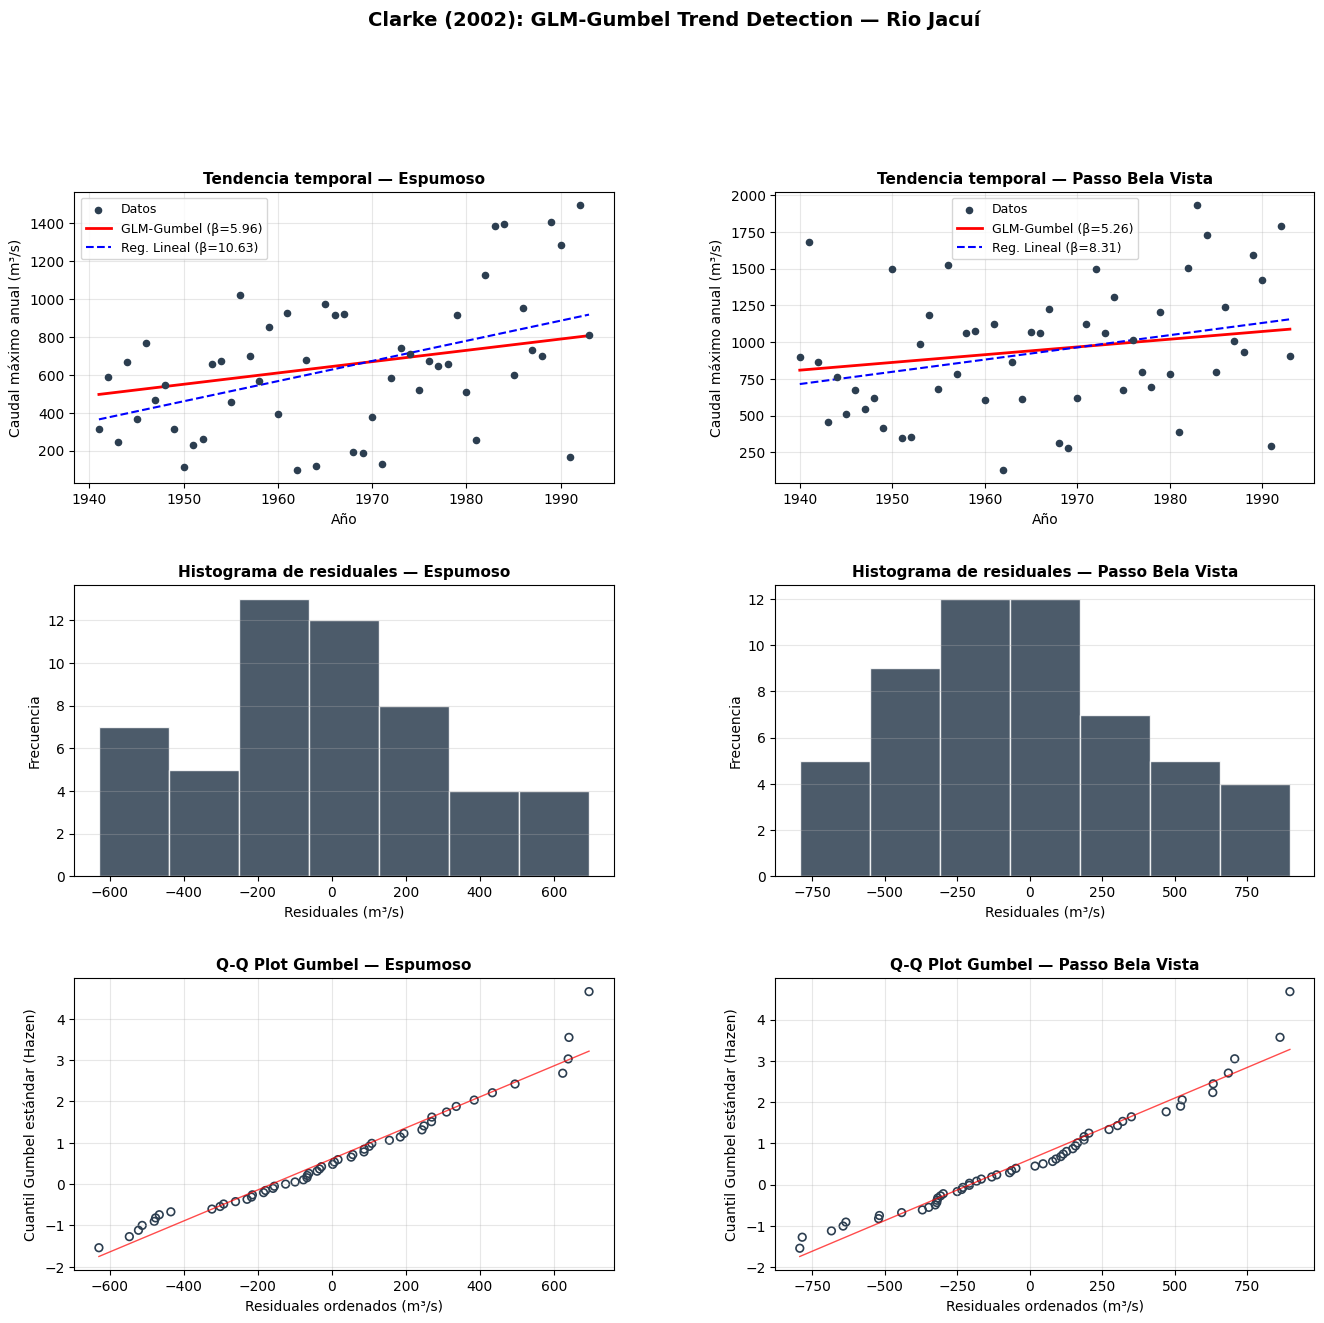

In [ ]:
# =============================================================================
# 7. EJECUCIÓN PRINCIPAL
# =============================================================================

if __name__ == '__main__':

    print("\n" + "=" * 72)
    print("  ESTACIÓN: ESPUMOSO — Rio Jacuí, Brasil")
    print("=" * 72)
    res_esp = clarke_glm_gumbel(flows_espumoso, years_espumoso)
    lr_esp = linear_regression_trend(flows_espumoso, years_espumoso)
    mk_esp = mann_kendall_test(flows_espumoso)

    print(f"\n  --- Comparación con Regresión Lineal ---")
    print(f"  LR: β = {lr_esp['beta']:.2f} ± {lr_esp['se_beta']:.2f} "
          f"m³/s/año")
    print(f"  LR: R² = {lr_esp['R2'] * 100:.1f}%")
    print(f"  LR: p-value = {lr_esp['p_value']:.6f}")

    print(f"\n  --- Mann-Kendall ---")
    print(f"  Z = {mk_esp['Z']:.3f}, p-value = {mk_esp['p_value']:.6f}")

    print("\n\n" + "=" * 72)
    print("  ESTACIÓN: PASSO BELA VISTA — Rio Jacuí, Brasil")
    print("=" * 72)
    res_bv = clarke_glm_gumbel(flows_belavista, years_belavista)
    lr_bv = linear_regression_trend(flows_belavista, years_belavista)
    mk_bv = mann_kendall_test(flows_belavista)

    print(f"\n  --- Comparación con Regresión Lineal ---")
    print(f"  LR: β = {lr_bv['beta']:.2f} ± {lr_bv['se_beta']:.2f} "
          f"m³/s/año")
    print(f"  LR: R² = {lr_bv['R2'] * 100:.1f}%")
    print(f"  LR: p-value = {lr_bv['p_value']:.6f}")

    print(f"\n  --- Mann-Kendall ---")
    print(f"  Z = {mk_bv['Z']:.3f}, p-value = {mk_bv['p_value']:.6f}")

    # ---- Gráficas ----
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

    # Tendencias
    ax1 = fig.add_subplot(gs[0, 0])
    plot_trend(res_esp, lr_esp, 'Espumoso', ax1)
    ax2 = fig.add_subplot(gs[0, 1])
    plot_trend(res_bv, lr_bv, 'Passo Bela Vista', ax2)

    # Histogramas
    ax3 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[2, 0])
    plot_gumbel_diagnostics(res_esp, 'Espumoso', ax3, ax5)

    ax4 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[2, 1])
    plot_gumbel_diagnostics(res_bv, 'Passo Bela Vista', ax4, ax6)

    plt.suptitle('Clarke (2002): GLM-Gumbel Trend Detection — Rio Jacuí',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('/home/Tarea_/clarke2002_results.png', dpi=150,
                bbox_inches='tight')
    print("\n\nFigura guardada: clarke2002_results.png")

    # ---- Tabla de convergencia (Tabla 2) ----
    print("\n\n" + "=" * 72)
    print("TABLA 2: Convergencia del algoritmo IWLS")
    print("=" * 72)
    print(f"\n{'':>4s}  {'--- Espumoso ---':^36s}  {'--- Passo Bela Vista ---':^36s}")
    print(f"{'Iter':>4s}  {'α̂':>10s}  {'m̂':>10s}  {'β̂':>10s}  "
          f"{'α̂':>10s}  {'m̂':>10s}  {'β̂':>10s}")
    print("-" * 72)

    max_rows = max(len(res_esp['history']), len(res_bv['history']))
    for i in range(max_rows):
        if i < len(res_esp['history']):
            he = res_esp['history'][i]
            e_str = f"{he['alpha']:>10.6f}  {he['m']:>10.2f}  {he['beta']:>10.4f}"
        else:
            e_str = f"{'':>10s}  {'':>10s}  {'':>10s}"

        if i < len(res_bv['history']):
            hb = res_bv['history'][i]
            b_str = f"{hb['alpha']:>10.6f}  {hb['m']:>10.2f}  {hb['beta']:>10.4f}"
        else:
            b_str = f"{'':>10s}  {'':>10s}  {'':>10s}"

        print(f"{i + 1:>4d}  {e_str}  {b_str}")

    print(f"{'ML':>4s}  {res_esp['alpha']:>10.6f}  {res_esp['m']:>10.2f}  "
          f"{res_esp['beta']:>10.4f}  "
          f"{res_bv['alpha']:>10.6f}  {res_bv['m']:>10.2f}  "
          f"{res_bv['beta']:>10.4f}")

    # ---- Simulación de potencia (reducida para velocidad) ----
    print("\n")
    sigma = np.pi / np.sqrt(6)
    table3, table4 = power_simulation(
        N_samples=100, N_size=50,
        beta_values=[0.0, 0.5 * sigma / 50, sigma / 50, 2 * sigma / 50],
        seed=42
    )

    plt.close('all')

# [ANEXO2] Replicación del código general para la ventana (1950-1990)
*(Script generado orientación a partir de Claude-IA)*

Ventana: 1950-1990, N = 41 observaciones
t = 11...51
Media = 664.5, Std = 362.6
Min = 99, Max = 1407

RESULTADOS COMPARATIVOS — ESPUMOSO 1950-1990

--- GLM-Gumbel (ML) ---
  α = 0.003469  (σ = 288.27)
  m = 112.58
  β = 12.7387 m³/s/año
  Intercepto = 278.98
  χ² = 8.034, p = 0.0046

--- Regresión Lineal (OLS) ---
  Intercepto = 224.66
  β = 14.1873 ± 4.2810 m³/s/año
  t-stat = 3.314, p = 0.0020
  R² = 22.0%
  σ_residual = 324.34

--- Momentos (MoM) ---
  α = 0.004005  (σ = 249.71)
  m = 80.52
  β = 14.1873 m³/s/año
  Intercepto = 224.66
  IC 95% bootstrap de β: (5.5001, 21.4371)
  p (bootstrap) = 0.0030

--- L-momentos (PWM) ---
  α = 0.003724  (σ = 268.54)
  m = 69.65
  β = 14.1873 m³/s/año
  Intercepto = 224.66
  L1 = 224.66, L2 = 186.14

--- ML Directa (Nelder-Mead) ---
  α = 0.003469  (σ = 288.27)
  m = 112.58
  β = 12.7387 m³/s/año
  Intercepto = 278.98
  χ² = 8.034, p = 0.0046
  Convergió: True

TABLA COMPARATIVA DE ESTIMACIONES
Método                     β (tend.)          α   

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/window_comparison.png'

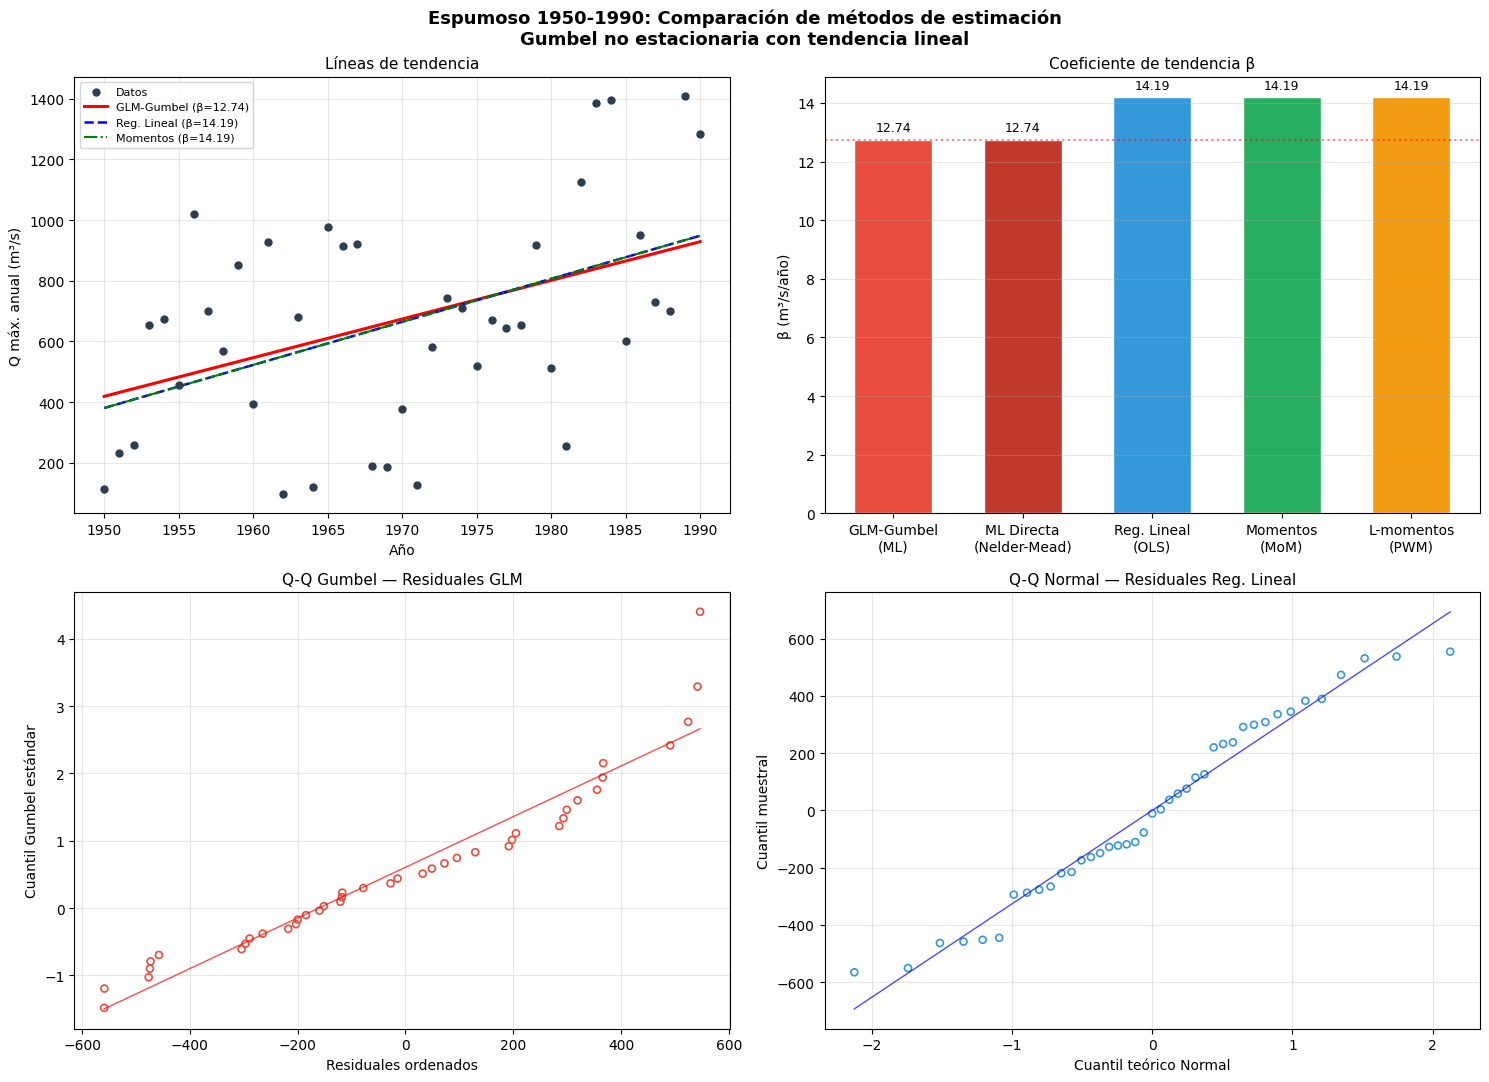

In [ ]:
"""
Análisis de ventana 1950-1990 para Espumoso:
Comparación de métodos de estimación de tendencia en Gumbel no estacionaria.

Métodos comparados:
1. GLM-Gumbel (ML) — Clarke (2002)
2. Regresión Lineal (OLS) — asume normalidad
3. Momentos ponderados por probabilidad (PWM / L-momentos)
4. Método de Momentos (MoM) con tendencia
"""

import numpy as np
from scipy.optimize import brentq, minimize
from scipy.stats import chi2, norm, gumbel_r
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =====================================================================
# DATOS ESPUMOSO (1941-1993) — Tabla 1 de Clarke (2002)
# =====================================================================
years_full = np.arange(1941, 1994)
flows_full = np.array([
    312, 590, 248, 670, 365, 770, 465, 545, 315, 115,
    232, 260, 655, 675, 455, 1020, 700, 570, 853, 395,
    926, 99, 680, 121, 976, 916, 921, 191, 187, 377,
    128, 582, 744, 710, 520, 672, 645, 655, 918, 512,
    255, 1126, 1386, 1394, 600, 950, 731, 700, 1407, 1284,
    165, 1496, 809
], dtype=float)

# =====================================================================
# VENTANA 1950-1990
# =====================================================================
mask = (years_full >= 1950) & (years_full <= 1990)
years = years_full[mask]
Q = flows_full[mask]
N = len(Q)
t = years - 1939  # misma convención del paper

print(f"Ventana: {years[0]}-{years[-1]}, N = {N} observaciones")
print(f"t = {t[0]}...{t[-1]}")
print(f"Media = {np.mean(Q):.1f}, Std = {np.std(Q, ddof=1):.1f}")
print(f"Min = {Q.min():.0f}, Max = {Q.max():.0f}")

# =====================================================================
# MÉTODO 1: GLM-GUMBEL (ML) — Clarke (2002)
# =====================================================================
# (Reutilizando las funciones del script principal)

def gumbel_initial_alpha(y):
    s = np.std(y, ddof=1)
    return np.pi / (s * np.sqrt(6))

def glm_iwls_gumbel(y, X, alpha, max_iter=50, tol=1e-8):
    w = np.exp(-alpha * y)
    log_w = np.log(w)
    beta_glm = np.linalg.lstsq(X, log_w, rcond=None)[0]
    for _ in range(max_iter):
        eta = X @ beta_glm
        mu = np.exp(eta)
        z_work = eta + (w - mu) / mu
        beta_new = np.linalg.lstsq(X, z_work, rcond=None)[0]
        if np.max(np.abs(beta_new - beta_glm)) < tol:
            beta_glm = beta_new
            break
        beta_glm = beta_new
    eta = X @ beta_glm
    mu_hat = np.exp(eta)
    r = w / mu_hat
    deviance = 2.0 * np.sum(r - 1.0 - np.log(r))
    return beta_glm, mu_hat, deviance

def solve_alpha_ml(y, m, beta_trend, X_trend, alpha_current):
    def eq8(a):
        res = y - m - X_trend @ beta_trend
        return len(y)/a - np.sum(res) + np.sum(res * np.exp(-a * res))
    try:
        return brentq(eq8, alpha_current*0.01, alpha_current*100, xtol=1e-12)
    except ValueError:
        return alpha_current

def gumbel_logL(y, a, m, beta, t):
    res = y - m - beta * t
    return len(y) * np.log(a) - a * np.sum(res) - np.sum(np.exp(-a * res))

def fit_glm_gumbel(y, t_vec, max_iter=30, tol=1e-7):
    """Ajuste completo GLM-Gumbel con tendencia lineal."""
    N = len(y)
    X = np.column_stack([np.ones(N), t_vec])
    X_trend = t_vec.reshape(-1, 1)
    alpha = gumbel_initial_alpha(y)

    history = []
    for outer in range(1, max_iter + 1):
        beta_glm, _, dev = glm_iwls_gumbel(y, X, alpha)
        m = -beta_glm[0] / alpha
        b = -beta_glm[1] / alpha
        alpha_new = solve_alpha_ml(y, m, np.array([b]), X_trend, alpha)
        history.append({'iter': outer, 'alpha': alpha, 'm': m, 'b': b})
        if abs(alpha_new - alpha) < tol * alpha:
            alpha = alpha_new
            beta_glm, _, dev = glm_iwls_gumbel(y, X, alpha)
            m = -beta_glm[0] / alpha
            b = -beta_glm[1] / alpha
            break
        alpha = alpha_new

    # H0: sin tendencia
    X0 = np.ones((N, 1))
    a0 = gumbel_initial_alpha(y)
    for _ in range(max_iter):
        bg0, _, _ = glm_iwls_gumbel(y, X0, a0)
        m0 = -bg0[0] / a0
        a0_new = solve_alpha_ml(y, m0, np.array([0.0]), np.zeros((N,1)), a0)
        if abs(a0_new - a0) < tol * a0:
            a0 = a0_new
            bg0, _, _ = glm_iwls_gumbel(y, X0, a0)
            m0 = -bg0[0] / a0
            break
        a0 = a0_new

    logL_H1 = gumbel_logL(y, alpha, m, b, t_vec)
    logL_H0 = gumbel_logL(y, a0, m0, 0, t_vec)
    chi2_val = -2 * (logL_H0 - logL_H1)
    p_val = 1 - chi2.cdf(chi2_val, df=1)

    gamma_euler = 0.5772156649
    intercept = m + gamma_euler / alpha

    return {
        'method': 'GLM-Gumbel (ML)',
        'alpha': alpha, 'm': m, 'b': b,
        'intercept': intercept,
        'sigma': 1/alpha,
        'chi2': chi2_val, 'p_value': p_val,
        'logL_H1': logL_H1, 'logL_H0': logL_H0,
        'history': history
    }


# =====================================================================
# MÉTODO 2: REGRESIÓN LINEAL (OLS)
# =====================================================================
def fit_lr(y, t_vec):
    """Regresión lineal simple: Y = a + b*t + error Normal."""
    N = len(y)
    X = np.column_stack([np.ones(N), t_vec])
    beta_lr = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta_lr
    residuals = y - y_hat
    RSS = np.sum(residuals**2)
    s2 = RSS / (N - 2)
    XtX_inv = np.linalg.inv(X.T @ X)
    se_b = np.sqrt(s2 * XtX_inv[1, 1])
    from scipy.stats import t as t_dist
    t_stat = beta_lr[1] / se_b
    p_val = 2 * (1 - t_dist.cdf(abs(t_stat), df=N-2))
    R2 = 1 - RSS / np.sum((y - np.mean(y))**2)

    return {
        'method': 'Regresión Lineal (OLS)',
        'intercept': beta_lr[0], 'b': beta_lr[1],
        'se_b': se_b, 't_stat': t_stat,
        'p_value': p_val, 'R2': R2,
        'sigma_residual': np.sqrt(s2)
    }


# =====================================================================
# MÉTODO 3: MOMENTOS (MoM) CON TENDENCIA
# =====================================================================
def fit_mom_trend(y, t_vec):
    """
    Método de Momentos para Gumbel no estacionaria.
    1. Regresión lineal de Y sobre t → pendiente b_mom
    2. Residuales e_i = y_i - b_mom * t_i
    3. Parámetros de Gumbel por momentos sobre residuales
    """
    N = len(y)
    gamma_euler = 0.5772156649

    # Paso 1: pendiente por OLS
    X = np.column_stack([np.ones(N), t_vec])
    beta_lr = np.linalg.lstsq(X, y, rcond=None)[0]
    b_mom = beta_lr[1]

    # Paso 2: residuales (removiendo tendencia lineal)
    residuals = y - b_mom * t_vec

    # Paso 3: estimadores Gumbel por momentos sobre residuales
    r_mean = np.mean(residuals)
    r_std = np.std(residuals, ddof=1)

    alpha_mom = np.pi / (r_std * np.sqrt(6))
    m_mom = r_mean - gamma_euler / alpha_mom

    intercept = m_mom + gamma_euler / alpha_mom  # = r_mean

    # No hay test de verosimilitud propiamente dicho.
    # Se usa bootstrap para intervalo de confianza de b
    np.random.seed(42)
    n_boot = 2000
    b_boot = np.zeros(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(N, N, replace=True)
        y_b = y[idx]
        t_b = t_vec[idx]
        X_b = np.column_stack([np.ones(len(t_b)), t_b])
        beta_b = np.linalg.lstsq(X_b, y_b, rcond=None)[0]
        b_boot[i] = beta_b[1]

    se_b_boot = np.std(b_boot, ddof=1)
    ci_lower = np.percentile(b_boot, 2.5)
    ci_upper = np.percentile(b_boot, 97.5)
    # p-value aproximado: proporción de bootstrap que cruza cero
    p_val_boot = 2 * min(np.mean(b_boot > 0), np.mean(b_boot < 0))

    return {
        'method': 'Momentos (MoM)',
        'alpha': alpha_mom, 'm': m_mom, 'b': b_mom,
        'intercept': intercept,
        'sigma': 1/alpha_mom,
        'se_b_bootstrap': se_b_boot,
        'ci_95': (ci_lower, ci_upper),
        'p_value': p_val_boot
    }


# =====================================================================
# MÉTODO 4: L-MOMENTOS (PWM) CON TENDENCIA
# =====================================================================
def fit_lmom_trend(y, t_vec):
    """
    L-momentos (Probability Weighted Moments) para Gumbel no estacionaria.
    1. Remover tendencia OLS
    2. Estimar parámetros Gumbel por L-momentos sobre residuales

    Para la Gumbel:
      λ₁ = m + γ/α  (L-location = media)
      λ₂ = log(2)/α  (L-scale)

    Entonces:
      α = log(2)/λ₂
      m = λ₁ - γ/α
    """
    N = len(y)
    gamma_euler = 0.5772156649

    # Paso 1: pendiente por OLS
    X = np.column_stack([np.ones(N), t_vec])
    beta_lr = np.linalg.lstsq(X, y, rcond=None)[0]
    b_lmom = beta_lr[1]

    # Paso 2: residuales
    residuals = y - b_lmom * t_vec

    # Paso 3: L-momentos de los residuales
    res_sorted = np.sort(residuals)

    # PWM: b_r = (1/N) * sum{ C(i-1, r) / C(N-1, r) * x_(i) }
    # L1 = b0
    # L2 = 2*b1 - b0
    from scipy.special import comb

    b0 = np.mean(res_sorted)
    b1 = np.sum([(i) / (N * (N-1)) * res_sorted[i] for i in range(N)])

    L1 = b0
    L2 = 2 * b1 - b0

    # Parámetros Gumbel por L-momentos
    alpha_lmom = np.log(2) / L2
    m_lmom = L1 - gamma_euler / alpha_lmom

    intercept = m_lmom + gamma_euler / alpha_lmom

    return {
        'method': 'L-momentos (PWM)',
        'alpha': alpha_lmom, 'm': m_lmom, 'b': b_lmom,
        'intercept': intercept,
        'sigma': 1/alpha_lmom,
        'L1': L1, 'L2': L2
    }


# =====================================================================
# MÉTODO 5: ML DIRECTA (Newton-Raphson / Nelder-Mead)
# =====================================================================
def fit_ml_direct(y, t_vec):
    """Máxima verosimilitud directa con Nelder-Mead."""
    N = len(y)
    gamma_euler = 0.5772156649

    def neglogL(params):
        m, b, alpha = params
        if alpha <= 0:
            return 1e15
        res = alpha * (y - m - b * t_vec)
        return -(N * np.log(alpha) - np.sum(res) - np.sum(np.exp(-res)))

    # Inicialización cuidadosa
    s = np.std(y, ddof=1)
    a0 = np.pi / (s * np.sqrt(6))
    b0 = np.polyfit(t_vec, y, 1)[0]
    m0 = np.mean(y) - gamma_euler / a0 - b0 * np.mean(t_vec)

    res = minimize(neglogL, [m0, b0, a0], method='Nelder-Mead',
                   options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':100000})

    m_ml, b_ml, alpha_ml = res.x
    logL_H1 = -res.fun

    # H0
    def neglogL_H0(params):
        m, alpha = params
        if alpha <= 0:
            return 1e15
        res = alpha * (y - m)
        return -(N * np.log(alpha) - np.sum(res) - np.sum(np.exp(-res)))

    res0 = minimize(neglogL_H0, [m0, a0], method='Nelder-Mead',
                    options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':100000})
    logL_H0 = -res0.fun

    chi2_val = -2 * (logL_H0 - logL_H1)
    p_val = 1 - chi2.cdf(chi2_val, df=1)

    intercept = m_ml + gamma_euler / alpha_ml

    return {
        'method': 'ML Directa (Nelder-Mead)',
        'alpha': alpha_ml, 'm': m_ml, 'b': b_ml,
        'intercept': intercept,
        'sigma': 1/alpha_ml,
        'chi2': chi2_val, 'p_value': p_val,
        'logL_H1': logL_H1, 'logL_H0': logL_H0,
        'converged': res.success
    }


# =====================================================================
# EJECUTAR TODOS LOS MÉTODOS
# =====================================================================

print("\n" + "="*75)
print("RESULTADOS COMPARATIVOS — ESPUMOSO 1950-1990")
print("="*75)

# 1. GLM-Gumbel (ML)
r1 = fit_glm_gumbel(Q, t)
print(f"\n--- {r1['method']} ---")
print(f"  α = {r1['alpha']:.6f}  (σ = {r1['sigma']:.2f})")
print(f"  m = {r1['m']:.2f}")
print(f"  β = {r1['b']:.4f} m³/s/año")
print(f"  Intercepto = {r1['intercept']:.2f}")
print(f"  χ² = {r1['chi2']:.3f}, p = {r1['p_value']:.4f}")

# 2. Regresión Lineal
r2 = fit_lr(Q, t)
print(f"\n--- {r2['method']} ---")
print(f"  Intercepto = {r2['intercept']:.2f}")
print(f"  β = {r2['b']:.4f} ± {r2['se_b']:.4f} m³/s/año")
print(f"  t-stat = {r2['t_stat']:.3f}, p = {r2['p_value']:.4f}")
print(f"  R² = {r2['R2']*100:.1f}%")
print(f"  σ_residual = {r2['sigma_residual']:.2f}")

# 3. Momentos (MoM)
r3 = fit_mom_trend(Q, t)
print(f"\n--- {r3['method']} ---")
print(f"  α = {r3['alpha']:.6f}  (σ = {r3['sigma']:.2f})")
print(f"  m = {r3['m']:.2f}")
print(f"  β = {r3['b']:.4f} m³/s/año")
print(f"  Intercepto = {r3['intercept']:.2f}")
print(f"  IC 95% bootstrap de β: ({r3['ci_95'][0]:.4f}, {r3['ci_95'][1]:.4f})")
print(f"  p (bootstrap) = {r3['p_value']:.4f}")

# 4. L-momentos
r4 = fit_lmom_trend(Q, t)
print(f"\n--- {r4['method']} ---")
print(f"  α = {r4['alpha']:.6f}  (σ = {r4['sigma']:.2f})")
print(f"  m = {r4['m']:.2f}")
print(f"  β = {r4['b']:.4f} m³/s/año")
print(f"  Intercepto = {r4['intercept']:.2f}")
print(f"  L1 = {r4['L1']:.2f}, L2 = {r4['L2']:.2f}")

# 5. ML Directa
r5 = fit_ml_direct(Q, t)
print(f"\n--- {r5['method']} ---")
print(f"  α = {r5['alpha']:.6f}  (σ = {r5['sigma']:.2f})")
print(f"  m = {r5['m']:.2f}")
print(f"  β = {r5['b']:.4f} m³/s/año")
print(f"  Intercepto = {r5['intercept']:.2f}")
print(f"  χ² = {r5['chi2']:.3f}, p = {r5['p_value']:.4f}")
print(f"  Convergió: {r5['converged']}")


# =====================================================================
# TABLA COMPARATIVA
# =====================================================================
print("\n" + "="*75)
print("TABLA COMPARATIVA DE ESTIMACIONES")
print("="*75)
print(f"{'Método':<25s} {'β (tend.)':>10s} {'α':>10s} {'σ':>10s} "
      f"{'Intercept':>10s} {'p-value':>10s}")
print("-"*75)

methods = [
    (r1['method'][:24], r1['b'], r1['alpha'], r1['sigma'], r1['intercept'], r1['p_value']),
    (r5['method'][:24], r5['b'], r5['alpha'], r5['sigma'], r5['intercept'], r5['p_value']),
    (r2['method'][:24], r2['b'], None, r2['sigma_residual'], r2['intercept'], r2['p_value']),
    (r3['method'][:24], r3['b'], r3['alpha'], r3['sigma'], r3['intercept'], r3['p_value']),
    (r4['method'][:24], r4['b'], r4['alpha'], r4['sigma'], r4['intercept'], None),
]

for name, b, a, s, inter, p in methods:
    a_str = f"{a:.6f}" if a else "N/A"
    p_str = f"{p:.4f}" if p else "N/A"
    print(f"{name:<25s} {b:>10.4f} {a_str:>10s} {s:>10.2f} "
          f"{inter:>10.2f} {p_str:>10s}")


# =====================================================================
# ANÁLISIS CON REGISTRO COMPLETO vs VENTANA PARA REFERENCIA
# =====================================================================
print("\n" + "="*75)
print("COMPARACIÓN: REGISTRO COMPLETO (1941-1993) vs VENTANA (1950-1990)")
print("="*75)

t_full = years_full - 1939
r_full = fit_glm_gumbel(flows_full, t_full)

print(f"\n{'Parámetro':<20s} {'Completo (N=53)':>18s} {'Ventana (N=41)':>18s} {'Diferencia':>12s}")
print("-"*70)
print(f"{'N':<20s} {53:>18d} {N:>18d}")
print(f"{'α':<20s} {r_full['alpha']:>18.6f} {r1['alpha']:>18.6f} {(r1['alpha']-r_full['alpha'])/r_full['alpha']*100:>11.1f}%")
print(f"{'m':<20s} {r_full['m']:>18.2f} {r1['m']:>18.2f} {r1['m']-r_full['m']:>12.2f}")
print(f"{'β (tend.)':<20s} {r_full['b']:>18.4f} {r1['b']:>18.4f} {r1['b']-r_full['b']:>12.4f}")
print(f"{'σ (= 1/α)':<20s} {r_full['sigma']:>18.2f} {r1['sigma']:>18.2f} {r1['sigma']-r_full['sigma']:>12.2f}")
print(f"{'Intercepto':<20s} {r_full['intercept']:>18.2f} {r1['intercept']:>18.2f} {r1['intercept']-r_full['intercept']:>12.2f}")
print(f"{'χ²':<20s} {r_full['chi2']:>18.3f} {r1['chi2']:>18.3f}")
print(f"{'p-value':<20s} {r_full['p_value']:>18.6f} {r1['p_value']:>18.6f}")


# =====================================================================
# GRÁFICA COMPARATIVA
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Espumoso 1950-1990: Comparación de métodos de estimación\n'
             'Gumbel no estacionaria con tendencia lineal',
             fontsize=13, fontweight='bold')

gamma_euler = 0.5772156649

# --- Panel 1: Tendencias superpuestas ---
ax = axes[0, 0]
ax.scatter(years, Q, s=25, color='#2c3e50', zorder=3, label='Datos')

# GLM-Gumbel
trend_glm = r1['intercept'] + r1['b'] * t
ax.plot(years, trend_glm, 'r-', lw=2.2, label=f"GLM-Gumbel (β={r1['b']:.2f})")

# Regresión Lineal
trend_lr = r2['intercept'] + r2['b'] * t
ax.plot(years, trend_lr, 'b--', lw=1.8, label=f"Reg. Lineal (β={r2['b']:.2f})")

# Momentos
trend_mom = r3['intercept'] + r3['b'] * t
ax.plot(years, trend_mom, 'g-.', lw=1.5, label=f"Momentos (β={r3['b']:.2f})")

ax.set_title('Líneas de tendencia', fontsize=11)
ax.set_xlabel('Año')
ax.set_ylabel('Q máx. anual (m³/s)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 2: Comparación de β ---
ax = axes[0, 1]
methods_names = ['GLM-Gumbel\n(ML)', 'ML Directa\n(Nelder-Mead)', 'Reg. Lineal\n(OLS)',
                 'Momentos\n(MoM)', 'L-momentos\n(PWM)']
betas = [r1['b'], r5['b'], r2['b'], r3['b'], r4['b']]
colors = ['#e74c3c', '#c0392b', '#3498db', '#27ae60', '#f39c12']

bars = ax.bar(methods_names, betas, color=colors, edgecolor='white', width=0.6)
ax.axhline(y=r1['b'], color='red', linestyle=':', alpha=0.5, label='β ML')
ax.set_title('Coeficiente de tendencia β', fontsize=11)
ax.set_ylabel('β (m³/s/año)')
ax.grid(axis='y', alpha=0.3)

# Anotar valores
for bar, val in zip(bars, betas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# --- Panel 3: Q-Q plot residuales GLM ---
ax = axes[1, 0]
residuals_glm = Q - (r1['intercept'] + r1['b'] * t)
res_sorted = np.sort(residuals_glm)
hazen = (np.arange(1, N+1) - 0.5) / N
gumbel_q = -np.log(-np.log(hazen))

ax.scatter(res_sorted, gumbel_q, s=25, facecolors='none', edgecolors='#e74c3c', lw=1.2)
coeffs = np.polyfit(res_sorted, gumbel_q, 1)
x_line = np.array([res_sorted.min(), res_sorted.max()])
ax.plot(x_line, coeffs[0]*x_line + coeffs[1], 'r-', lw=1, alpha=0.7)
ax.set_title('Q-Q Gumbel — Residuales GLM', fontsize=11)
ax.set_xlabel('Residuales ordenados')
ax.set_ylabel('Cuantil Gumbel estándar')
ax.grid(alpha=0.3)

# --- Panel 4: Q-Q plot residuales LR ---
ax = axes[1, 1]
residuals_lr = Q - (r2['intercept'] + r2['b'] * t)
res_sorted_lr = np.sort(residuals_lr)
from scipy.stats import probplot
(osm, osr), (slope, intercept_qq, r_val) = probplot(residuals_lr, dist='norm')
ax.scatter(osm, osr, s=25, facecolors='none', edgecolors='#3498db', lw=1.2)
ax.plot(osm, slope*np.array(osm) + intercept_qq, 'b-', lw=1, alpha=0.7)
ax.set_title('Q-Q Normal — Residuales Reg. Lineal', fontsize=11)
ax.set_xlabel('Cuantil teórico Normal')
ax.set_ylabel('Cuantil muestral')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/window_comparison.png', dpi=150, bbox_inches='tight')
print("\n\nFigura guardada: window_comparison.png")


# =====================================================================
# ANÁLISIS DE SENSIBILIDAD: EFECTO DE LA VENTANA EN β
# =====================================================================
print("\n" + "="*75)
print("SENSIBILIDAD: β SEGÚN VENTANA TEMPORAL")
print("="*75)

print(f"\n{'Ventana':<16s} {'N':>4s}  {'β_GLM':>8s}  {'β_LR':>8s}  "
      f"{'p_GLM':>8s}  {'p_LR':>8s}  {'Δβ':>8s}")
print("-"*60)

windows = [
    (1941, 1993),  # completo
    (1941, 1980),
    (1950, 1990),
    (1955, 1990),
    (1960, 1993),
    (1950, 1993),
]

for y_start, y_end in windows:
    mask_w = (years_full >= y_start) & (years_full <= y_end)
    y_w = flows_full[mask_w]
    t_w = years_full[mask_w] - 1939
    n_w = len(y_w)

    try:
        rg = fit_glm_gumbel(y_w, t_w)
        rl = fit_lr(y_w, t_w)
        delta = rl['b'] - rg['b']
        print(f"{y_start}-{y_end:<9d} {n_w:>4d}  {rg['b']:>8.2f}  {rl['b']:>8.2f}  "
              f"{rg['p_value']:>8.4f}  {rl['p_value']:>8.4f}  {delta:>8.2f}")
    except Exception as e:
        print(f"{y_start}-{y_end:<9d} {n_w:>4d}  ERROR: {e}")